In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from matplotlib.ticker import FuncFormatter

DATA_PATH = Path("dataset.csv")

PAYMENT_LABELS = {
    "Credit Card": "Кредитная карта",
    "Debit Card": "Дебетовая карта",
    "PayPal": "PayPal",
    "Cash": "Наличные",
    "Bank Transfer": "Банковский перевод",
}
SHIPPING_LABELS = {
    "Standard": "Стандартная",
    "Express": "Экспресс",
    "Overnight": "Ночная",
    "Same Day": "В день заказа",
    "Expedited": "Ускоренная",
}
PRODUCT_LABELS = {
    "Smartphone": "Смартфон",
    "Tablet": "Планшет",
    "Laptop": "Ноутбук",
    "Smartwatch": "Смарт-часы",
    "Headphones": "Наушники",
}

pd.set_option("display.float_format", lambda value: f"{value:,.2f}".replace(",", " "))
pd.set_option("display.max_rows", 20)

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "figure.figsize": (9, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 13,
})


## Подготовка данных

In [2]:
def load_orders(path: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    orders = pd.read_csv(path)
    orders["Purchase Date"] = pd.to_datetime(orders["Purchase Date"])
    orders["Payment Method"] = orders["Payment Method"].replace({"Paypal": "PayPal"})
    orders["Order Total"] = orders["Total Price"] + orders["Add-on Total"]
    orders["Month"] = orders["Purchase Date"].dt.to_period("M")
    orders["Quarter"] = orders["Purchase Date"].dt.to_period("Q")
    completed = orders.loc[orders["Order Status"].eq("Completed")].copy()
    return orders, completed


def format_money(value: float, digits: int = 0) -> str:
    return f"{value:,.{digits}f}".replace(",", " ")


orders, completed = load_orders(DATA_PATH)

print(f"Строк в файле: {len(orders):,}".replace(",", " "))
print(f"Завершённых заказов: {len(completed):,}".replace(",", " "))
print(f"Покупателей: {orders['Customer ID'].nunique():,}".replace(",", " "))
print(
    "Период:",
    orders["Purchase Date"].min().date(),
    "—",
    orders["Purchase Date"].max().date(),
)
orders["Order Status"].value_counts()


Строк в файле: 20 000
Завершённых заказов: 13 432
Покупателей: 12 136
Период: 2023-09-24 — 2024-09-23


Order Status
Completed    13432
Cancelled     6568
Name: count, dtype: int64

## Задание 1. Покупатели

Таблица ниже содержит каждого покупателя из файла. У покупателей, у которых все заказы отменены, общие траты и траты на дополнения равны нулю.


In [3]:
def preferred_payment(frame: pd.DataFrame) -> pd.Series:
    stats = (
        frame.groupby(["Customer ID", "Payment Method"], as_index=False)
        .agg(order_count=("Payment Method", "size"), spend=("Order Total", "sum"))
        .sort_values(
            ["Customer ID", "order_count", "spend", "Payment Method"],
            ascending=[True, False, False, True],
        )
    )
    return stats.drop_duplicates("Customer ID").set_index("Customer ID")["Payment Method"]


def customer_profile(orders: pd.DataFrame, completed: pd.DataFrame) -> pd.DataFrame:
    preferred_completed = preferred_payment(completed)
    preferred_any = preferred_payment(orders)
    preferred = preferred_completed.reindex(preferred_any.index).fillna(preferred_any)

    spending = completed.groupby("Customer ID").agg(
        total_spend=("Order Total", "sum"),
        addon_spend=("Add-on Total", "sum"),
    )
    profile = preferred.to_frame(name="preferred_payment").join(spending, how="left")
    profile["total_spend"] = profile["total_spend"].fillna(0.0)
    profile["addon_spend"] = profile["addon_spend"].fillna(0.0)
    profile["preferred_payment"] = profile["preferred_payment"].map(PAYMENT_LABELS)

    missing_labels = profile["preferred_payment"].isna().sum()
    if missing_labels:
        raise ValueError(f"Неизвестный метод оплаты у {missing_labels} покупателей")

    profile = profile.reset_index().rename(
        columns={
            "Customer ID": "ID покупателя",
            "preferred_payment": "Предпочитаемый метод оплаты",
            "total_spend": "Общие траты",
            "addon_spend": "Траты на доп. услуги и аксессуары",
        }
    )
    return profile.sort_values("ID покупателя").reset_index(drop=True)


customers = customer_profile(orders, completed)
paid = customers.loc[customers["ID покупателя"].isin(completed["Customer ID"])]
print(f"Покупателей в таблице: {len(customers):,}".replace(",", " "))
print(f"Из них с завершёнными заказами: {len(paid):,}".replace(",", " "))
print()
print("Предпочитаемый метод среди покупателей с завершёнными заказами:")
print(paid["Предпочитаемый метод оплаты"].value_counts().to_string())
print()
customers.head(15)


Покупателей в таблице: 12 136
Из них с завершёнными заказами: 9 466

Предпочитаемый метод среди покупателей с завершёнными заказами:
Предпочитаемый метод оплаты
PayPal                2745
Кредитная карта       2715
Банковский перевод    1574
Наличные              1218
Дебетовая карта       1214



,ID покупателя,Предпочитаемый метод оплаты,Общие траты,Траты на доп. услуги и аксессуары
0,1000,PayPal,767.18,26.09
1,1002,Наличные,5 080.76,60.16
2,1003,Наличные,77.06,35.56
3,1004,Кредитная карта,148.78,65.78
4,1005,PayPal,11 854.44,75.33
5,1006,Наличные,6 736.32,90.38
6,1007,Кредитная карта,0.00,0.00
7,1008,Наличные,3 445.17,65.85
8,1011,Кредитная карта,7 982.07,70.17
9,1013,PayPal,0.00,0.00


In [4]:
customer_1000 = customers.loc[customers["ID покупателя"].eq(1000)].iloc[0]
customer_1002 = customers.loc[customers["ID покупателя"].eq(1002)].iloc[0]

assert customer_1000["Предпочитаемый метод оплаты"] == "PayPal"
assert abs(customer_1000["Общие траты"] - 767.18) < 0.01
assert abs(customer_1000["Траты на доп. услуги и аксессуары"] - 26.09) < 0.01

assert customer_1002["Предпочитаемый метод оплаты"] == "Наличные"
assert abs(customer_1002["Общие траты"] - 5080.76) < 0.01
assert abs(customer_1002["Траты на доп. услуги и аксессуары"] - 60.16) < 0.01

print("Проверка покупателей 1000 и 1002 прошла.")
print(
    "1000: один завершённый заказ, PayPal,",
    format_money(customer_1000["Общие траты"], 2),
    "всего, из них",
    format_money(customer_1000["Траты на доп. услуги и аксессуары"], 2),
    "на дополнения.",
)
print(
    "1002: кредитная карта и наличные по одному завершённому заказу;",
    "больше денег прошло через наличные, поэтому предпочитаемый метод — наличные.",
)


Проверка покупателей 1000 и 1002 прошла.
1000: один завершённый заказ, PayPal, 767.18 всего, из них 26.09 на дополнения.
1002: кредитная карта и наличные по одному завершённому заказу; больше денег прошло через наличные, поэтому предпочитаемый метод — наличные.


## Задание 2. Доход

Доход по доставке и по типу продукта в каждой таблице складывается в одну и ту же сумму: это весь доход завершённых заказов. Месяц и квартал показывают только часть этого дохода — дополнительные услуги и аксессуары.

Сентябрь 2023 в данных начинается с 24-го числа, сентябрь 2024 заканчивается 23-м. Квартал 2023 Q3 поэтому состоит из одной неполной недели.


In [5]:
def revenue_by(frame: pd.DataFrame, column: str, label: str, labels: dict[str, str]) -> pd.DataFrame:
    revenue = (
        frame.groupby(column, as_index=False)["Order Total"]
        .sum()
        .rename(columns={column: label, "Order Total": "Доход"})
        .sort_values("Доход", ascending=False)
        .reset_index(drop=True)
    )
    revenue[label] = revenue[label].map(labels)
    if revenue[label].isna().any():
        raise ValueError(f"Неизвестное значение в столбце {column}")
    return revenue


def addon_revenue_by_period(frame: pd.DataFrame, column: str, label: str) -> pd.DataFrame:
    revenue = (
        frame.groupby(column, as_index=False)["Add-on Total"]
        .sum()
        .rename(columns={column: label, "Add-on Total": "Доход"})
    )
    revenue[label] = revenue[label].astype(str)
    if column == "Quarter":
        revenue[label] = revenue[label].map(lambda value: value.replace("Q", " Q"))
    return revenue


shipping_revenue = revenue_by(completed, "Shipping Type", "Метод доставки", SHIPPING_LABELS)
product_revenue = revenue_by(completed, "Product Type", "Тип продукта", PRODUCT_LABELS)
addon_by_month = addon_revenue_by_period(completed, "Month", "Месяц")
addon_by_quarter = addon_revenue_by_period(completed, "Quarter", "Квартал")

order_revenue = completed["Order Total"].sum()
addon_revenue = completed["Add-on Total"].sum()

if abs(shipping_revenue["Доход"].sum() - order_revenue) > 0.01:
    raise AssertionError("Доход по доставке не сходится с суммой заказов")
if abs(product_revenue["Доход"].sum() - order_revenue) > 0.01:
    raise AssertionError("Доход по типам продуктов не сходится с суммой заказов")
if abs(customers["Общие траты"].sum() - order_revenue) > 0.01:
    raise AssertionError("Сумма трат покупателей не сходится с доходом заказов")
if abs(addon_by_month["Доход"].sum() - addon_revenue) > 0.01:
    raise AssertionError("Месячный доход от дополнений не сходится")
if abs(addon_by_quarter["Доход"].sum() - addon_revenue) > 0.01:
    raise AssertionError("Квартальный доход от дополнений не сходится")
if abs(customers["Траты на доп. услуги и аксессуары"].sum() - addon_revenue) > 0.01:
    raise AssertionError("Траты покупателей на дополнения не сходятся с доходом")

print("Доход по методу доставки")
display(shipping_revenue)
print("Доход по типу продукта")
display(product_revenue)
print("Доход по дополнительным услугам и аксессуарам за месяц")
display(addon_by_month)
print("Доход по дополнительным услугам и аксессуарам за квартал")
display(addon_by_quarter)


Доход по методу доставки


,Метод доставки,Доход
0,Стандартная,14 676 351.95
1,Ускоренная,8 610 437.09
2,В день заказа,8 469 574.60
3,Ночная,5 982 983.40
4,Экспресс,5 725 863.77


Доход по типу продукта


,Тип продукта,Доход
0,Смартфон,14 630 325.53
1,Смарт-часы,9 557 416.02
2,Ноутбук,8 536 583.03
3,Планшет,7 893 431.51
4,Наушники,2 847 454.72


Доход по дополнительным услугам и аксессуарам за месяц


,Месяц,Доход
0,2023-09,5 337.61
1,2023-10,26 153.21
2,2023-11,24 453.33
3,2023-12,22 750.23
4,2024-01,93 254.95
5,2024-02,80 253.72
6,2024-03,84 713.93
7,2024-04,82 294.06
8,2024-05,89 374.18
9,2024-06,84 648.60


Доход по дополнительным услугам и аксессуарам за квартал


,Квартал,Доход
0,2023 Q3,5 337.61
1,2023 Q4,73 356.77
2,2024 Q1,258 222.60
3,2024 Q2,256 316.84
4,2024 Q3,242 361.42


## Графики

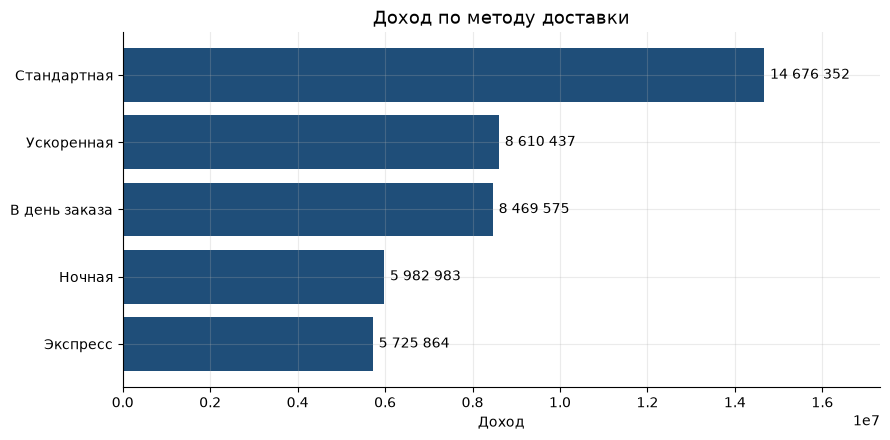

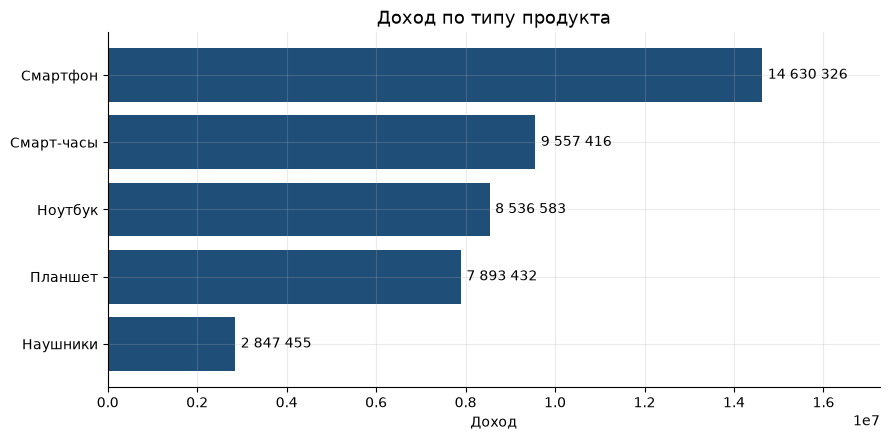

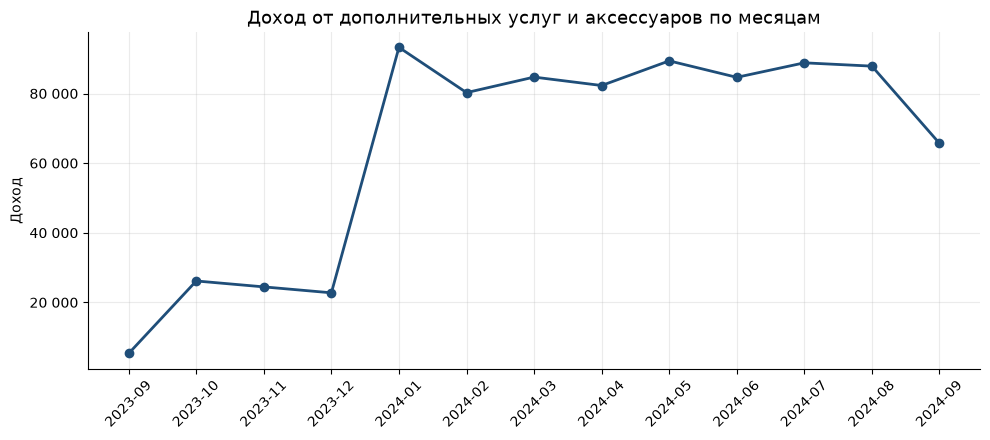

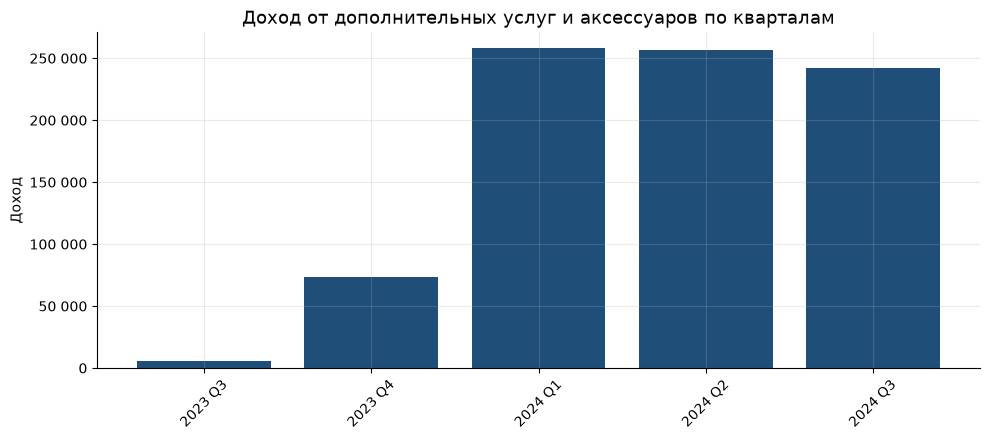

In [6]:
def plot_horizontal_bars(frame: pd.DataFrame, category_col: str, title: str) -> None:
    ordered = frame.sort_values("Доход", ascending=True)
    fig, ax = plt.subplots()
    bars = ax.barh(ordered[category_col], ordered["Доход"], color="#1F4E79")
    ax.set_title(title)
    ax.set_xlabel("Доход")
    ax.bar_label(
        bars,
        labels=[format_money(value) for value in ordered["Доход"]],
        padding=4,
    )
    ax.set_xlim(0, ordered["Доход"].max() * 1.18)
    fig.tight_layout()
    plt.show()


def plot_period_series(frame: pd.DataFrame, period_col: str, title: str, kind: str) -> None:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    if kind == "line":
        ax.plot(
            frame[period_col],
            frame["Доход"],
            color="#1F4E79",
            marker="o",
            linewidth=2,
        )
    elif kind == "bar":
        ax.bar(frame[period_col], frame["Доход"], color="#1F4E79")
    else:
        raise ValueError(f"Неизвестный тип графика: {kind}")
    ax.set_title(title)
    ax.set_ylabel("Доход")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _pos: format_money(value)))
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    plt.show()


plot_horizontal_bars(shipping_revenue, "Метод доставки", "Доход по методу доставки")
plot_horizontal_bars(product_revenue, "Тип продукта", "Доход по типу продукта")
plot_period_series(
    addon_by_month,
    "Месяц",
    "Доход от дополнительных услуг и аксессуаров по месяцам",
    "line",
)
plot_period_series(
    addon_by_quarter,
    "Квартал",
    "Доход от дополнительных услуг и аксессуаров по кварталам",
    "bar",
)


## Что видно по цифрам

In [7]:
top_shipping = shipping_revenue.iloc[0]
top_product = product_revenue.iloc[0]
paid_preferences = paid["Предпочитаемый метод оплаты"].value_counts()
addon_share = addon_revenue / order_revenue * 100

print(
    f"Завершённые заказы принесли {format_money(order_revenue, 2)}. "
    f"Из них {format_money(addon_revenue, 2)} "
    f"({addon_share:.1f}%) — дополнительные услуги и аксессуары."
)
print(
    "Самые частые предпочитаемые методы — "
    f"«{paid_preferences.index[0]}» ({format_money(paid_preferences.iloc[0])} покупателей) "
    f"и «{paid_preferences.index[1]}» ({format_money(paid_preferences.iloc[1])})."
)
print(
    f"Больше всего дохода приходится на доставку «{top_shipping['Метод доставки']}»: "
    f"{format_money(top_shipping['Доход'], 2)}. "
    f"Среди продуктов впереди «{top_product['Тип продукта']}»: "
    f"{format_money(top_product['Доход'], 2)}."
)
print(
    "На графике по месяцам сентябрь 2023 ниже остальных: "
    "в выборку попали только дни с 24 сентября. "
    "С января 2024 доход от дополнений держится примерно в одном диапазоне, "
    "и кварталы 2024 Q1–Q3 близки друг к другу. "
    "Квартал 2023 Q3 — это та же неполная неделя сентября."
)


Завершённые заказы принесли 43 465 210.81. Из них 835 595.24 (1.9%) — дополнительные услуги и аксессуары.
Самые частые предпочитаемые методы — «PayPal» (2 745 покупателей) и «Кредитная карта» (2 715).
Больше всего дохода приходится на доставку «Стандартная»: 14 676 351.95. Среди продуктов впереди «Смартфон»: 14 630 325.53.
На графике по месяцам сентябрь 2023 ниже остальных: в выборку попали только дни с 24 сентября. С января 2024 доход от дополнений держится примерно в одном диапазоне, и кварталы 2024 Q1–Q3 близки друг к другу. Квартал 2023 Q3 — это та же неполная неделя сентября.
